In [ ]:
# Autoreload files
%load_ext autoreload
%autoreload 2

#import camera_module
import os

import numpy as np

os.environ["OPENCV_IO_ENABLE_OPENEXR"]="1"

from itertools import product
from pathlib import Path

# import camera simulation code
import camera_simulation_gpu as sim
import cv2
import image_comparer as comp
import matplotlib.pyplot as plt
import rawpy
from tqdm import tqdm

base_path = Path.cwd()
print(base_path)
path_to_exr_images = Path("H:/Subset/HDR_EXR")
path_to_cam_images = Path("H:/kamera_bilder_meta")
path_to_printed_images = Path("H:/gedruckt")
path_to_rectified_images = Path("H:printed_rectified")
path_to_ssd = Path("H:")
path_to_local_npy = Path("F:/Code/Repos/RDR2-RA/large_npy/")
print(path_to_local_npy)
img_path = "example_images/h_1000002_12.exr"

img = cv2.imread(img_path, flags=cv2.IMREAD_ANYDEPTH + cv2.IMREAD_COLOR)
if img is None:
    print("CV2 not loaded correctly")


### Simulate Camera

#### Simulate images and save simulations and histograms in npy matrix

##### Loop over Files

In [ ]:
input_factor = 5000
exr_directory = Path("H:/example_images/")
npy_dir = Path("./example_images/numpy_files/sim_images") / str(input_factor)
files = [f.stem for f in exr_directory.iterdir() if f.is_file()]
created_files = [f.stem for f in npy_dir.iterdir() if f.is_file()]
for name in tqdm(files, desc="Files"):
    if name in created_files:
        print(f"Skipping {name}, as it already exists")
        continue
    print(f"Create {name} Matrix")
    imgs = comp.simulate_images(exr_directory / (name + ".exr"))
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32), val_range=[0,256])
    np.save(npy_dir / name.split(".")[0], hists)
print("done")

##### Loop over Alpha values

In [ ]:
input_factors = range(170000, 200001, 10000)
name = "S2R-HDR"
npy_dir_repo = Path(f"./example_images/numpy_files/sim_images/{name}/")
npy_dir_ssd = Path(f"F:/Code/Repos/RDR2-RA/large_npy/sim_imgs_npy/{name}" )
print(npy_dir_ssd)
if not os.path.exists(npy_dir_repo):
    os.makedirs(npy_dir_repo)
if not os.path.exists(npy_dir_ssd):
    os.makedirs(npy_dir_ssd)
for factor in tqdm(input_factors, desc="Factors"):
    imgs = comp.simulate_images(Path(f"./example_images/{name}.exr"), input_factor=factor)
    #imgs = np.load(npy_dir_ssd /(name + "_" + str(factor) + "_imgs.npy"))   # For Loading already simulated npy files
    np.save(npy_dir_ssd /(name + "_" + str(factor) + "_imgs"), imgs)
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32), val_range=[0,256])
    np.save(npy_dir_repo /(name + "_" + str(factor) + "_hist"), hists)
print("done")

### Plot ARW Files

##### Plot PNGs

In [ ]:
directories = [str(f.name) for f in path_to_printed_images.iterdir() if not f.is_file()]

for image_name in tqdm(directories): #["wellersberg_hundeschule_nacht", "wellersberg_stadt_abend", "wellersberg_stadt_nacht"]:
    image_path = path_to_printed_images / image_name
    print(image_name)
    imgs = comp.load_image_files_to_matrix(image_path, extension="JPG", hw=(4000, 6000))#.astype(np.uint8)

    fig, ax = plt.subplots(9,3, figsize=(12,18))

    plt.title(image_name)
    for i in range(3):
        for j in range(3):
            for k in range(3):
                iso = sim.iso_values[i]
                shutter_speed = sim.shutter_speed_values[j]
                aperture = sim.aperture_values[k]
                image = imgs[i][k][j]#.astype(np.uint8)
                ax[k*3+i][j].imshow(image)
                ax[k*3+i][j].axis('off')
                ax[k*3+i][j].set_title(f"Iso: {iso} Sh: {shutter_speed:.3f} Ap: {aperture}")
    plt.tight_layout()
    plt.savefig("Cam_plots_printed_JPEG/" + image_name + "_plot.pdf", bbox_inches=None)
    plt.close(fig)
    print(f"{image_name} Plot Saved")
    print("*"*50)
#plt.show()

##### Plot Small Gray all Variants

In [ ]:

image_path = Path("F:/Code/Repos/RDR2-RA/large_npy/sim_imgs_npy/2014_000344/")
files = [f for f in image_path.iterdir()]
for file in tqdm(files):
    image_name = str(file.name).split(".")[0]
    path = "Sim_plots_Small/" + image_name + "_gray_plot.pdf"
    #print(path)
    #print(os.path.isfile(path))
    if os.path.isfile(path):
        #print("Skip")
        continue
    imgs = np.load(file).astype(np.uint8)#comp.load_image_files_to_matrix(image_path, extension="npy", hw=(4000, 6000), target_hw=(400,600))#.astype(np.uint8)  
    
    #imgs_small = np.zeros((3,3,3, 400, 600, 3))                                # VARIANT Scaling loaded images down for faster plotting
    #for i,j,k in product(range(3), range(3), range(3)):
    #    imgs_small[i][j][k] = cv2.resize(imgs[i][j][k],(600, 400)).astype(np.uint8)
    
    #np.save(f"example_images/numpy_files/sim_images/h_1000131_20/{image_name}_small", imgs_small)
    
    fig, ax = plt.subplots(3,9, figsize=(18,4), facecolor="#A1B7CC")

    for i in range(3):
        for j in range(3):
            for k in range(3):
                iso = sim.iso_values[i]
                shutter_speed = sim.shutter_speed_values[j]
                aperture = sim.aperture_values[k]
                image = imgs[i][k][j]#.astype(np.uint8)
                ax[i][k*3+j].imshow(image)
                ax[i][k*3+j].axis('off')
    plt.tight_layout()
    plt.savefig("Sim_plots_Small/" + image_name + "_gray_plot.pdf", bbox_inches=None)
    plt.close(fig)

##### Plot Visual Calibration

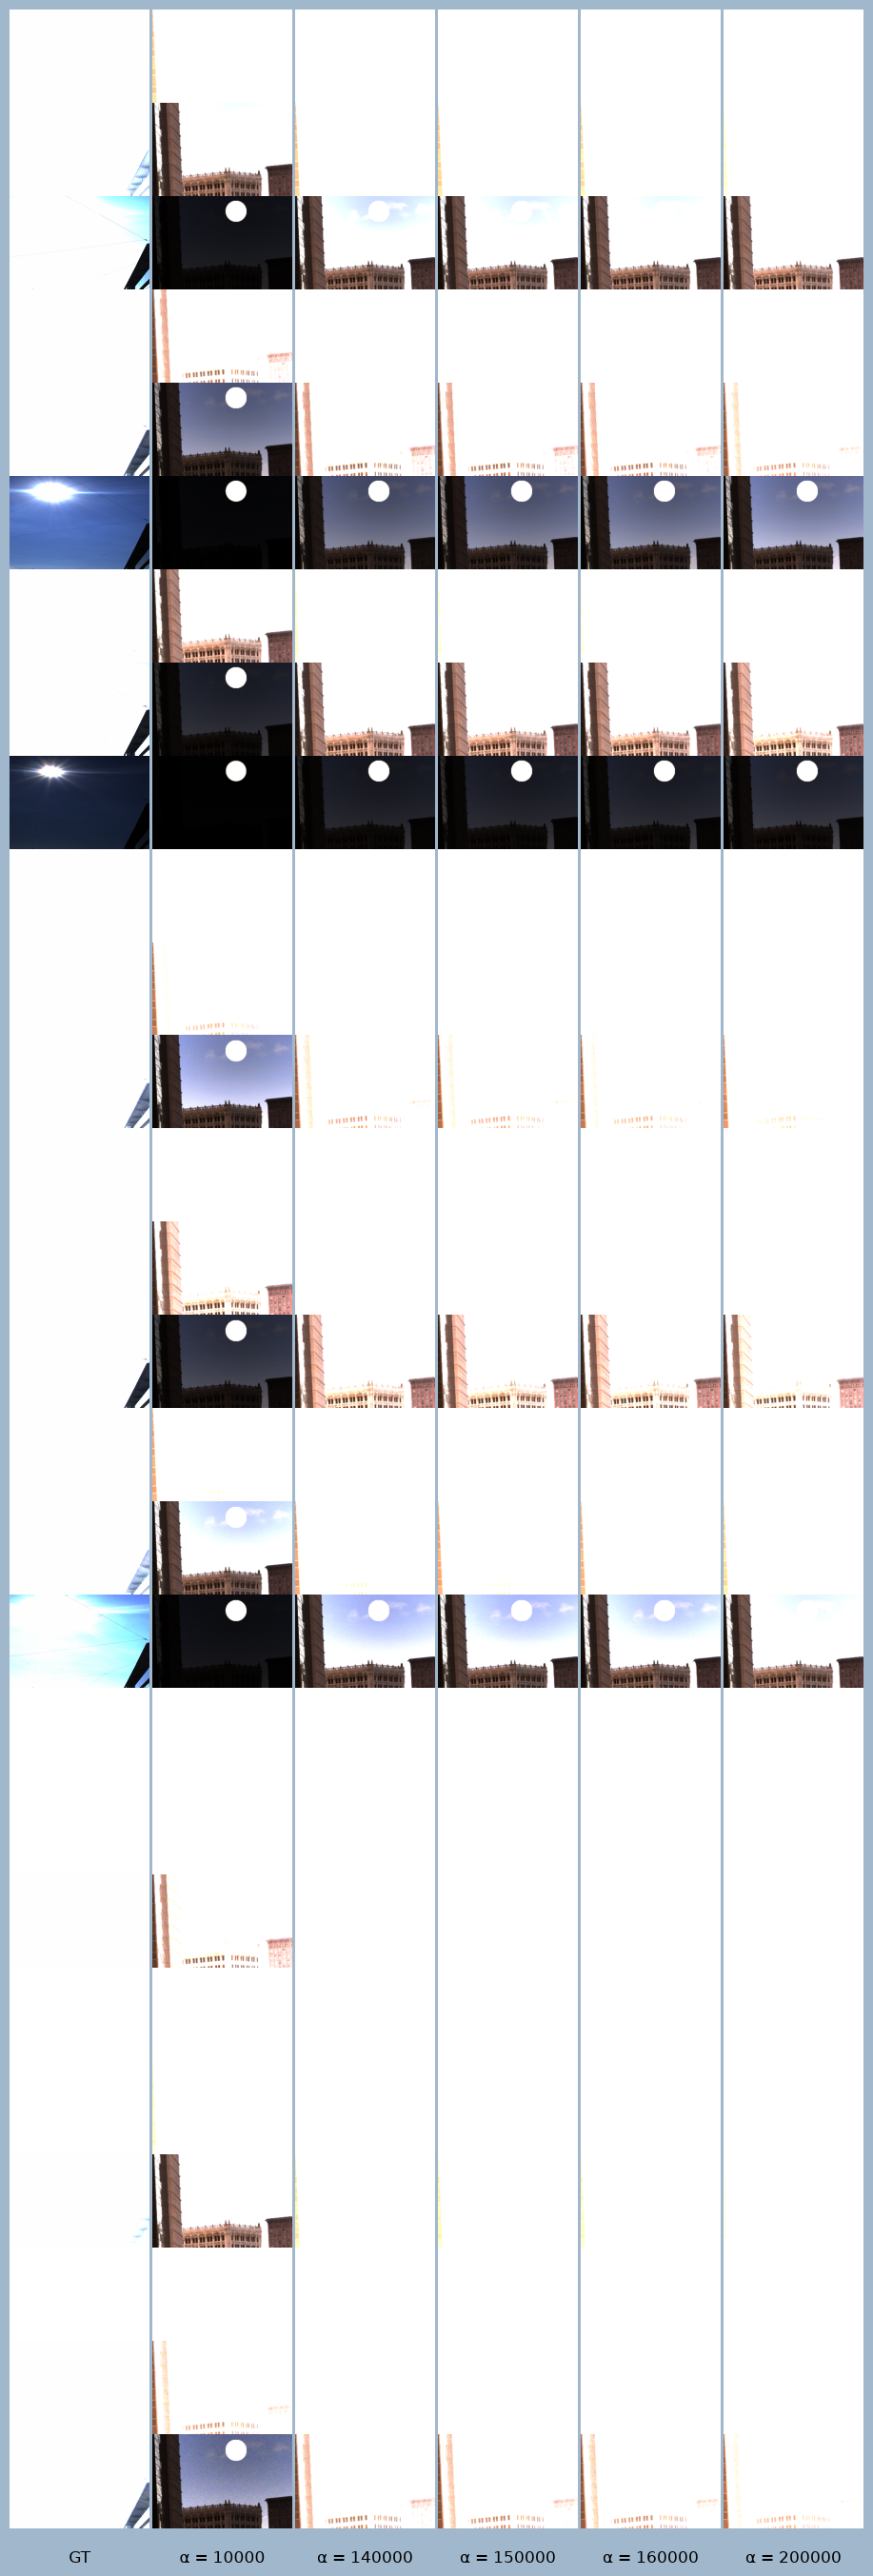

In [ ]:
#directories = [str(f.name) for f in path_to_cam_images.iterdir() if not f.is_file()]

#for image_name in tqdm(directories):
#image_path = path_to_cam_images / image_name
#image_path = Path("H:/sim_imgs_npy/h_1000131_20/")
GTPath = Path("C:/Users/dekav/Desktop/strasse_10") # path_to_cam_images / "charlottental_garten_hell" 
image_name = "S2R-HDR"
CompPath = Path(f"F:/Code/Repos/RDR2-RA/large_npy/sim_imgs_npy/{image_name}/")
path = "Sim_plots_Small/" + image_name + "_gray_plot.pdf"

gt_imgs = comp.load_image_files_to_matrix(GTPath, extension="ARW", hw=(4000, 6000),rot_k=3)#.astype(np.uint8)
#alphas = range(90000, 150001,10000)

alphas = [10000,140000,150000,160000,200000]                    # CHOOSE ALPHA VALUES TO PLOT
A = alphas.__len__()
gt_imgs_small = np.zeros((3,3,3, 2000, 3000, 3))#.astype(np.uint8)
for i,j,k in product(range(3), range(3), range(3)):
    gt_imgs_small[i][j][k] = gt_imgs[i][j][k][464:2464,1025:4025]#.astype(np.uint8) #1470:2070,2430:3330 white car 


comp_imgs_small = np.zeros((A,3,3,3, 200, 300, 3)).astype(np.uint8)
for a, alpha in enumerate(alphas):
    file = CompPath / f"{image_name}_{alpha}_imgs.npy"
    comp_imgs = np.load(file).astype(np.uint8)

    for i,j,k in product(range(3), range(3), range(3)):
        comp_imgs_small[a][i][j][k] = comp_imgs[i][j][k][216:416,712:1012].astype(np.uint8) #1000:3000,320:3320 white car





fig, ax = plt.subplots(
    27, A+1,
    figsize=(9, 27),
    gridspec_kw={
        "wspace": 0,
        "hspace": 0
    },
    facecolor="#A1B7CC"
)
for a in range(A+1):

    for i in range(3):
        for j in range(3):
            for k in range(3):
                iso = sim.iso_values[i]
                shutter_speed = sim.shutter_speed_values[j]
                aperture = sim.aperture_values[k]
                if a == 0:
                    image = gt_imgs_small[i][k][j]
                else:
                    image = comp_imgs_small[a-1][i][2-k][j]
                #image = imgs[a][i][k][j]#.astype(np.uint8)
                ax[i*9+k*3+j][a].imshow(image)
                ax[i*9+k*3+j][a].axis('off')

column_labels = ["GT"] + [f"α = {alpha}" for alpha in alphas]

for a, label in enumerate(column_labels):
    x = (a + 0.5) / (A + 1)
    fig.text(
        x,
        0.005,
        label,
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.subplots_adjust(
    left=0,
    right=1,
    top=1,
    bottom=0.02,
    wspace=0.0,
    hspace=0.0
)
plt.savefig("Plots/Calibration_plots/" + image_name + f"_strasse_10_{alphas[0]!s}-{alphas[-1]!s}_gray_plot_vert.pdf", bbox_inches=None)
plt.show()
plt.close(fig)


### Compare Sim and Cam

#### Save JPG files normalized histograms in npy matrix

In [ ]:
for name in ["strasse_9","strasse_10"]:
    imgs = comp.load_image_files_to_matrix(Path("C:/Users/dekav/Desktop/" + name), extension="JPG").astype(np.uint8)
    hists = comp.get_normalized_histogramm_of_matrix(imgs.astype(np.float32))
    np.save('example_images/numpy_files/cam_images/jpg_' + name + "_hist", hists)
print("done")

#### Compare from npy files

##### Create comparison Matrix for one simulation

In [ ]:
sim_path = base_path / "example_images/numpy_files/sim_images/h_1000131_20/h_1000131_20_2000_hist.npy"
cam_path = base_path / "example_images/numpy_files/cam_images/wellersberg_wald_abend_hist.npy"
comparison_matrix = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
#print(comparison_matrix)
print(np.average(comparison_matrix))

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]

0.48774546


##### Plot Comparison values

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\2146730559.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


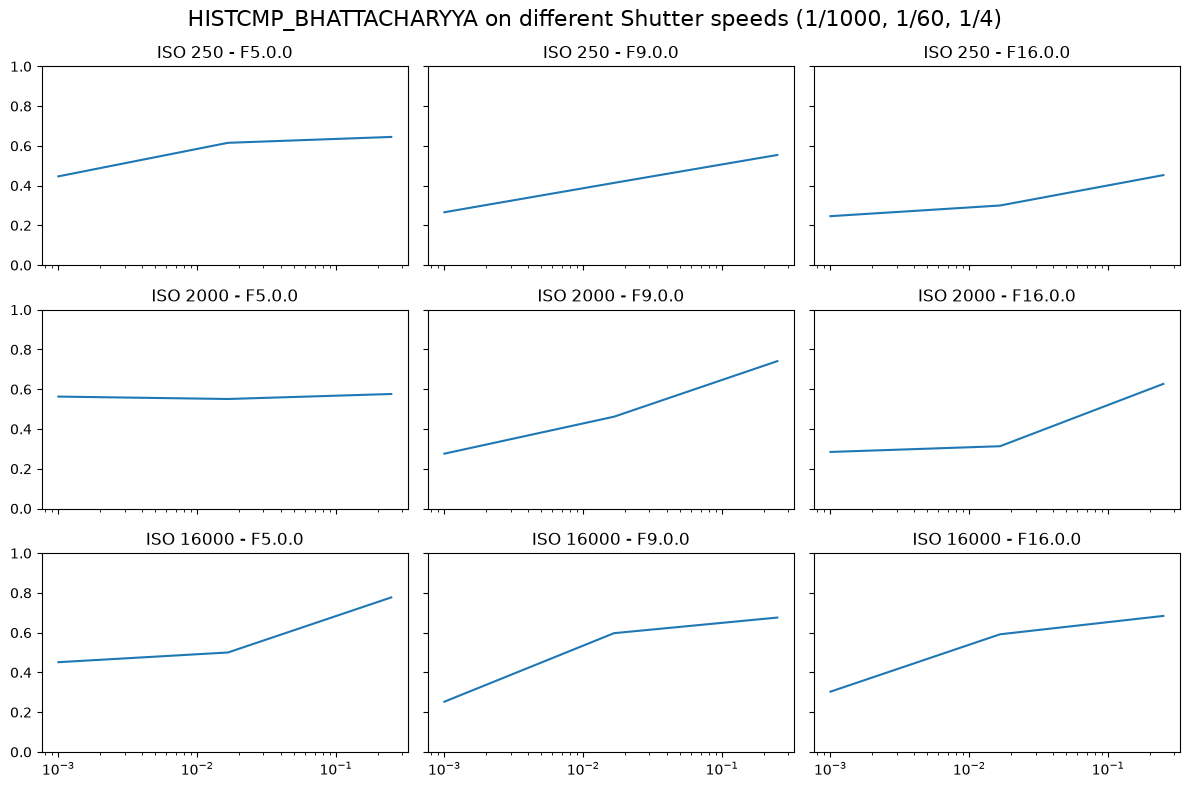

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
for i in range(3):
    for j in range(3):
        ax[i][j].plot(shs, comparison_matrix[i][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"ISO {isos[i]} - F{fs[j]}.0")
fig.suptitle("HISTCMP_BHATTACHARYYA on different Shutter speeds (1/1000, 1/60, 1/4)", fontsize=16)
plt.tight_layout()

fig.show()

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\2920192100.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


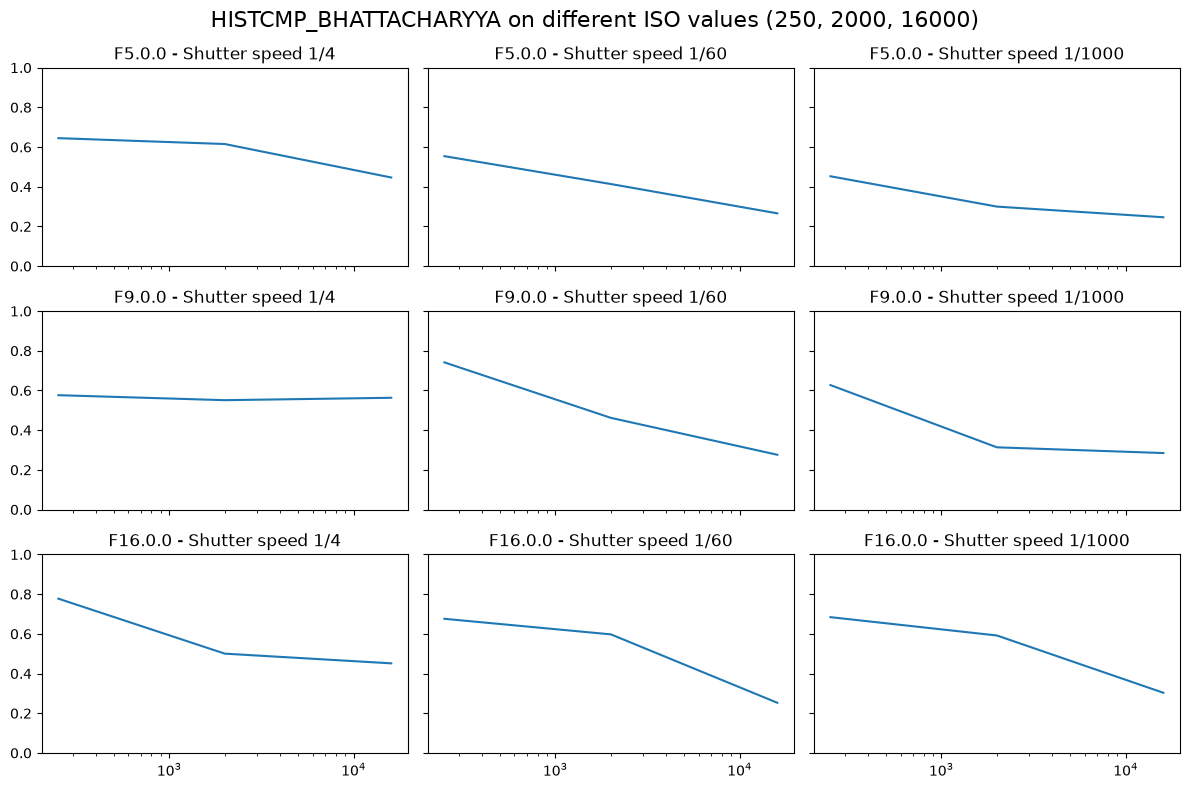

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
shs_str = sim.shutter_speed_values_str
for i in range(3):
    for j in range(3):
        ax[i][j].plot(isos, comparison_matrix[:][i][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"F{fs[i]}.0 - Shutter speed {shs_str[j]}")
fig.suptitle("HISTCMP_BHATTACHARYYA on different ISO values (250, 2000, 16000)", fontsize=16)
plt.tight_layout()

fig.show()

C:\Users\dekav\AppData\Local\Temp\ipykernel_3360\3805821002.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


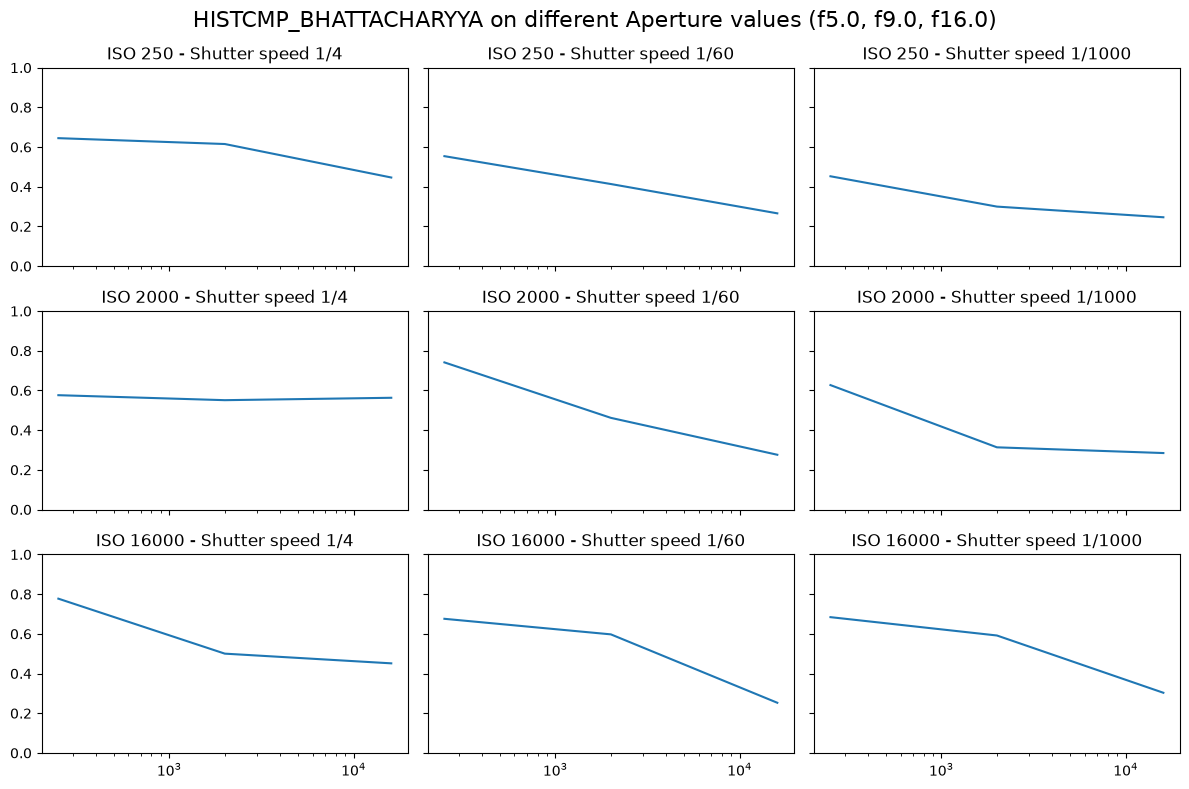

In [ ]:
fig, ax = plt.subplots(3,3, figsize=(12,8), sharex=True, sharey=True)

isos = sim.iso_values
fs = sim.aperture_values
shs = sim.shutter_speed_values
shs_str = sim.shutter_speed_values_str
for i in range(3):
    for j in range(3):
        ax[i][j].plot(isos, comparison_matrix[i][:][j])
        ax[i][j].set_xscale("log")
        ax[i][j].set_ylim(0,1)
        ax[i][j].title.set_text(f"ISO {isos[i]} - Shutter speed {shs_str[j]}")
fig.suptitle("HISTCMP_BHATTACHARYYA on different Aperture values (f5.0, f9.0, f16.0)", fontsize=16)
plt.tight_layout()

fig.show()

In [ ]:
cam_path = base_path / "example_images/numpy_files/cam_images/wellersberg_wald_abend_hist.npy"
comps_avg = {}
comps = {}
input_factors = [1000, 2000, 3000, 4000, 5000, 6000]
for f in input_factors:

    sim_path = base_path / f"example_images/numpy_files/sim_images/h_1000131_20/h_1000131_20_{f}_hist.npy"
    comparison_matrix = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    comps[f] = comparison_matrix
    comps_avg[f] = np.average(comparison_matrix) 

#print(comparison_matrix)
print(comps_avg)

NameError: name 'input_factors' is not defined

##### Compare Histogramms over several Simulations

[0.66665141 0.66665141 0.66665141 0.66665141 0.66665142 0.66665143
 0.66665143 0.66665143 0.66665144 0.66665147 0.6666515  0.66665158
 0.66665173 0.66665197 0.6666524 ]
[0.94200303 0.94693687 0.95109695 0.95457833 0.95764721 0.9602631
 0.96269455 0.96509794 0.96747155 0.96976282 0.97175437 0.97331686
 0.974498   0.97540471 0.97616288]
[1.82169971 1.83650834 1.84558712 1.85407602 1.86226984 1.86983891
 1.87830059 1.8870946  1.89524433 1.90313117 1.90961549 1.91491255
 1.91953639 1.92332511 1.926578  ]


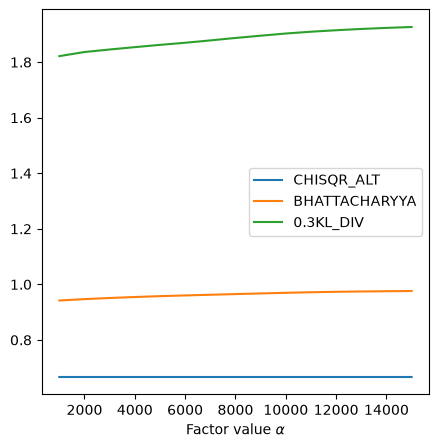

In [ ]:

comp_cam_img = "jpg_strasse_10"
orig_image_name = "S2R-HDR"

factor_values = range(1000, 15001, 1000)
#factor_values = [10000,20000, 30000, 35000, 40000, 45000, 50000, 60000, 70000, 80000, 90000, 10000]#[500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000]
#factor_values = [100000,150000,200000,250000, 300000, 350000, 400000, 450000, 500000,550000]
avg_results_1 = np.zeros(len(factor_values))
avg_results_2 = np.zeros(len(factor_values))
avg_results_3 = np.zeros(len(factor_values))
comparison_matrices_1 = np.zeros((len(factor_values),3,3,3,1)) 
comparison_matrices_2 = np.zeros((len(factor_values),3,3,3,1)) 
comparison_matrices_3 = np.zeros((len(factor_values),3,3,3,1)) 


for i, val in enumerate(factor_values):
    sim_path = base_path / f"example_images/numpy_files/sim_images/{orig_image_name}/{orig_image_name}_{val}_hist.npy"
    cam_path = base_path / f"example_images/numpy_files/cam_images/{comp_cam_img}_hist.npy"
    comparison_matrices_1[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_CHISQR_ALT)
    comparison_matrices_2[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    comparison_matrices_3[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_KL_DIV)
    avg_results_1[i] = np.average(comparison_matrices_1[i])
    avg_results_2[i] = np.average(comparison_matrices_2[i])
    avg_results_3[i] = np.average(comparison_matrices_3[i])*0.3
fig = plt.figure(figsize=(5,5))
plt.plot(factor_values, avg_results_1, label="CHISQR_ALT")
plt.plot(factor_values, avg_results_2, label="BHATTACHARYYA")
plt.plot(factor_values, avg_results_3, label="0.3KL_DIV")
print(avg_results_1)
print(avg_results_2)
print(avg_results_3)
plt.xlabel("Factor value $\\alpha$")
plt.legend()
#plt.title(f"Avg Histogram comparison over Factor Values\nComparing {comp_cam_img} and {orig_image_name}")
plt.savefig(f"Histogramm_comparison {comp_cam_img} {orig_image_name}.pdf")
plt.show()

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<00:00, 38584.74it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


...

f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<?, ?it/s]


f:\Code\Repos\RDR2-RA\camera_simulation\example_images\numpy_files\cam_images\wellersberg_wald_abend_hist.npy


Comparing: 100%|██████████| 27/27 [00:00<00:00, 27001.96it/s]

[0.49516833 0.48774552 0.49208214 0.49841487 0.50414069 0.50876252
 0.5141008  0.5190645  0.52436154 0.5297787 ]


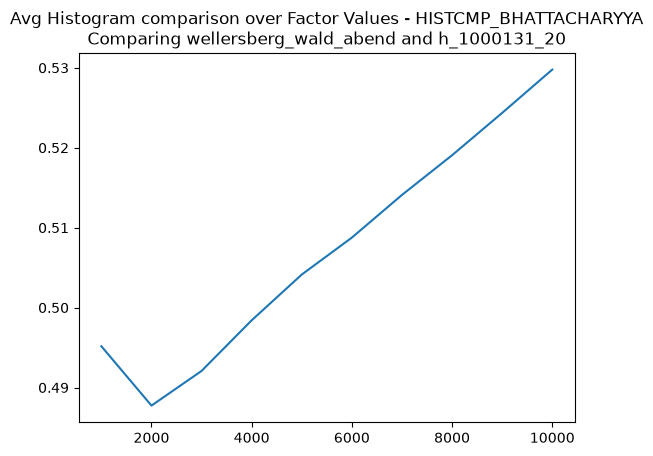

In [ ]:
avg_results = np.zeros(len(factor_values))
comparison_matrices = np.zeros((len(factor_values),3,3,3,1)) 
for i, val in enumerate(factor_values):
    sim_path = base_path / f"example_images/numpy_files/sim_images/{orig_image_name}/{orig_image_name}_{val}_hist.npy"
    cam_path = base_path / f"example_images/numpy_files/cam_images/{comp_cam_img}_hist.npy"
    comparison_matrices[i] = comp.compare_hist_matrix_from_path(sim_path, cam_path, method=cv2.HISTCMP_BHATTACHARYYA)
    avg_results[i] = np.average(comparison_matrices[i])
print(avg_results)
plt.plot(factor_values, avg_results)
plt.title(f"Avg Histogram comparison over Factor Values - HISTCMP_BHATTACHARYYA\nComparing {comp_cam_img} and {orig_image_name}")

plt.show()

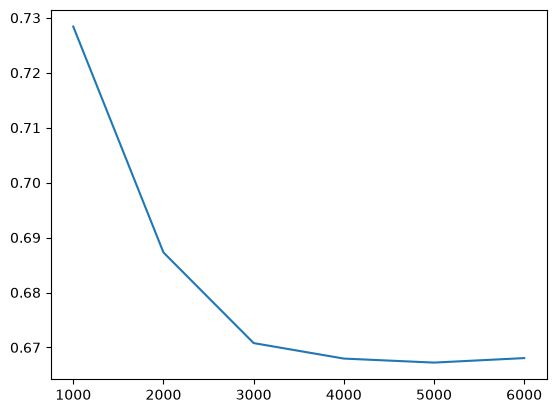

In [ ]:
plt.plot([1000, 2000, 3000, 4000, 5000, 6000], avg_results)
plt.show()

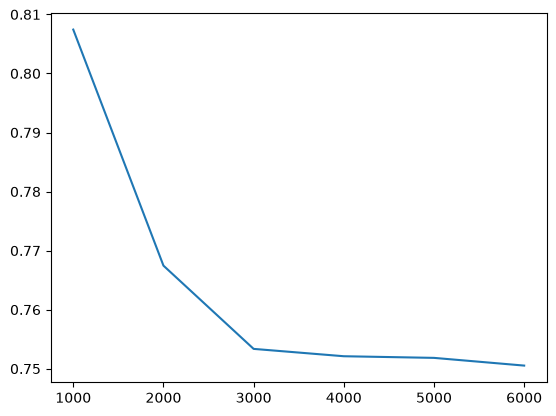

In [ ]:
plt.plot([1000, 2000, 3000, 4000, 5000, 6000], avg_results)
plt.show()

### Fix perspective of printed photos

In [ ]:
dir_name = "weiss"

# Four corners in the photo (pixel coordinates)
src_pts = np.asarray([
    [578, 560],   # TL
    [5361, 723],   # TR
    [5561, 3488],   # BR
    [656, 3626]   # BL
], dtype=np.float32)

# Desired output size
width = 6000
height = 4000

dst_pts = np.asarray([
    [0, 0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0, height - 1]
], dtype=np.float32)

# Compute perspective transform
H = cv2.getPerspectiveTransform(src_pts, dst_pts)

for i, j, k in tqdm(product(range(3), range(3), range(3)), total=27):
    iso = sim.iso_values[i]
    f = int(sim.aperture_values[j])
    sh_str = sim.shutter_speed_values_str[k].replace("/", "-")
    # Load image
    path = path_to_printed_images / f"{dir_name}/ISO{iso}_F{f}_sh{sh_str}.ARW"
    img = comp.load_arw_file(path, norm_factor=1)

    # Warp image
    rectified = cv2.warpPerspective(img, H, (width, height))
    rectified = cv2.cvtColor(rectified, cv2.COLOR_BGR2RGB) #  type: ignore
    #plt.imshow(rectified)
    cv2.imwrite(f"H:/printed_rectified/{dir_name}/ISO{iso}_F{f}_sh{sh_str}.png", rectified)

100%|██████████| 27/27 [02:17<00:00,  5.10s/it]


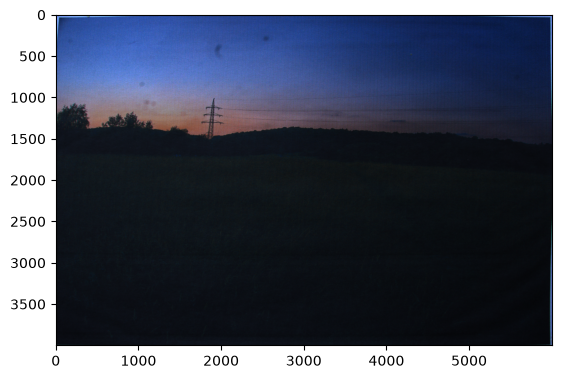

In [ ]:
iso = sim.iso_values[0]
f = int(sim.aperture_values[0])
sh_str = sim.shutter_speed_values_str[1].replace("/", "-")
read = plt.imread(f"H:/printed_rectified/{dir_name}/ISO{iso}_F{f}_sh{sh_str}.png")
plt.imshow(read)